# Classificateur d’images CNN

Nous allons voir un modèle **CNN** en action pour classifier des images.

Ce modèle a été entraîné à l’aide d’un jeu de données appelé CIFAR-10.
Le jeu de données CIFAR-10 contient 60 000 images couleur de taille 32×32 réparties en 10 classes, avec 6 000 images par classe.
Il comprend 50 000 images d’entraînement et 10 000 images de test.

Nous n’entraînerons pas le modèle ici, et utiliserons plutôt un point de contrôle pré-entraîné pour effectuer l’inférence.

<img src="./Assets/CIFAR10.png" style="max-width: 70%; height: auto; display: block; margin: 0 auto;" />

Source de cet exercice: Udacity @ https://github.com/udacity/deep-learning-v2-pytorch

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

In [ ]:
# Si vous exécutez ce notebook depuis Google Colab, veuillez d'abord cloner le dépôt pour avoir accès aux fichiers auxiliaires.

# !git clone https://github.com/geoaiclassroom/geoai_learning.git
# %cd geoai_learning
# %cd Tutorial3


## Préparation des données

Similaire à la mise à l'échelle des caractéristiques et au prétraitement que nous avons effectués, les images doivent être mises à l'échelle et dimensionnées de manière appropriée. Le mécanisme de mise à l'échelle et toute autre transformation dépendent des besoins du modèle. Ici, nous utilisons un modèle **pré-entraîné**, et nous devons donc nous en tenir aux transformations qui convertissent nos images dans la forme/format que ce modèle attend.

### Transformations

1. ToTensor : Convertit une image PIL ou un `numpy.ndarray` (H x L x C) dans la plage [0, 255] en un `torch.FloatTensor` de forme (C x H x L) dans la plage [0.0, 1.0]
2. Normalize : Normalise une image tenseur avec des moyennes et des écarts-types par bande.
3. Resize : Redimensionne l'image à la taille que le modèle s'attend à recevoir en entrée.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize(size = (32,32)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Voici les classes pour lesquelles notre modèles a été entrainé.

In [ ]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Chargeons maintenant l'image en mémoire et visualisons-la. 

In [ ]:
images = []
images.append(Image.open('sample1.jpg'))
images.append(Image.open('sample2.jpg'))

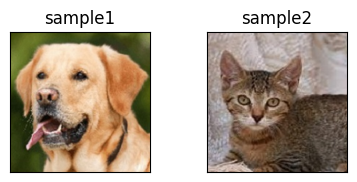

In [ ]:
# créer une figure
fig = plt.figure(figsize=(25, 4))
# afficher chaque image à l'aide d'une boucle for
for idx in range(len(images)):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    plt.imshow(images[idx])
    ax.set_title('sample'+str(idx + 1))

## Modèle CNN

Nous allons définir un modèle avec disons trois couches convolutives et deux couches FC (entièrement connectées).

Bien sûr, puisque nous utilisons un modèle pré-entraîné, nous devons nous assurer d'utiliser la même architecture que ce modèle.

Ensuite, nous créerons une instance (objet) de ce modèle et chargerons les paramètres entraînés depuis le fichier `.pt`.

In [ ]:
# définir l'architecture du modèle CNN
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Profondeur d'entrée, profondeur de sortie, taille du noyau (padding=1 signifie le même padding où la couche de sortie a la même taille que la couche d'entrée).
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 4 * 4, 500)
        self.fc2 = nn.Linear(500, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # ajouter une séquence de couches convolutionnelles et de max pooling
        x = self.pool(F.relu(self.conv1(x)))  # reçoit une entrée 32x32x3, retourne une sortie 16x16x16
        x = self.pool(F.relu(self.conv2(x)))  # retourne un tenseur 8x8x32
        x = self.pool(F.relu(self.conv3(x)))  # retourne un tenseur 4x4x64
        # aplatir l'entrée de l'image
        x = x.view(-1, 64 * 4 * 4) # retourne un vecteur de 64*4*4 dimensions
        # ajouter une couche de dropout
        x = self.dropout(x)
        # ajouter la 1ère couche cachée, avec fonction d'activation relu
        x = F.relu(self.fc1(x))  # retourne un vecteur de 500 dimensions
        # ajouter une couche de dropout
        x = self.dropout(x)
        # ajouter la 2ème couche cachée, avec fonction d'activation relu
        x = self.fc2(x)  # retourne un vecteur de 10 dimensions
        return x

# créer un objet CNN
model = Net()

In [ ]:
# charge le modèle entraîné et le met en mode évaluation/inférence (non-entraînement)!
model.load_state_dict(torch.load('model_augmented.pt', map_location=torch.device('cpu'), weights_only=True))
model.eval()

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

## Inférence
Nous sommes maintenant prêts à faire une **inférence** en utilisant ce modèle

In [ ]:
# Nous allons alimenter les images au modèle et voir la sortie

predicted_classes = []
for idx in range(len(images)):
    # transformer d'abord l'image de la manière attendue par le modèle en entrée
    img = transform(images[idx])
    # passage avant: calculer les sorties prédites en passant les entrées au modèle
    output_scores = model(img)
    # convertir les probabilités de sortie en classe prédite (score le plus élevé)
    _, pred_tensor = torch.max(output_scores, 1)
    pred = np.squeeze(pred_tensor.numpy())
    predicted_classes.append(classes[pred])
    print("sample {}".format(idx))
    print("\t Predicted scores: ", np.around(output_scores.detach().numpy()[0,:], 2))
    print("\t Predicted class: ", classes[pred])

sample 0
	 Predicted scores:  [-5.26 -3.51  0.75  2.78 -1.42  6.85  1.12  1.42 -4.65  0.37]
	 Predicted class:  dog
sample 1
	 Predicted scores:  [-0.75 -3.98  0.08  4.44  1.68  0.73  1.77 -2.65  0.83 -1.82]
	 Predicted class:  cat


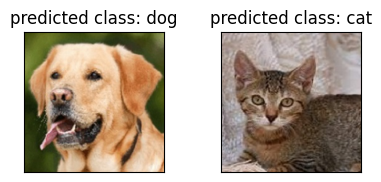

In [ ]:
# créer une figure
fig = plt.figure(figsize=(25, 4))
# afficher chaque image et la classe prédite comme titre
for idx in range(len(images)):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    # afficher les images
    plt.imshow(images[idx])
    # add title with the predicted class
    # ajouter un titre avec la classe prédite
    ax.set_title('predicted class: {}'.format(predicted_classes[idx]))
    


## Exercice
 Répéter l'inférence avec une autre image. Vous pouvez choisir une image d'auto ou d'avion prise sur internet, ou encore une image que vous avez sur votre ordinateur ou Google Drive. 